# 📈 Adım 8 — Performans Grafikleri

Bu notebook'ta 6 zorunlu grafik üretilmektedir:

| # | Grafik | Neyi gösteriyor? |
|---|--------|------------------|
| 1 | ROC Curve | Sensitivity vs Specificity dengesi |
| 2 | Precision-Recall Curve | Dengeli olmayan sınıflar için daha bilgilendirici |
| 3 | Confusion Matrix | Hangi tip hatayı kaç kez yapıyoruz? |
| 4 | Feature Importance | Hangi özellikler kararı etkiliyor? |
| 5 | Calibration Curve | Model olasılıkları gerçekçi mi? |
| 6 | Model Karşılaştırma | RF / ET / GB / Ensemble yan yana |

---

In [1]:
# ── Kütüphane İmportları ────────────────────────────────────────────────────
# Temel veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Ağaç tabanlı modeller (asıl modellerimiz — Optuna ile optimize edilecek)
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, VotingClassifier)

# Baseline modeller (karşılaştırma için — sabit parametreler)
from sklearn.linear_model import LogisticRegression   # Doğrusal sınır
from sklearn.svm import SVC                           # Kernel tabanlı
from sklearn.neighbors import KNeighborsClassifier    # Mesafe tabanlı

# Kalibrasyon ve çapraz doğrulama
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedGroupKFold

# Performans metrikleri
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, f1_score, accuracy_score
)

# Ön işleme araçları
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold

# MRMR özellik seçimi
from mrmr import mrmr_classif

# Optuna: Bayesci hiperparametre optimizasyonu (RF/ET/GB için)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Gereksiz log çıktısını kapat

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('Kütüphaneler hazır ✓')


Kütüphaneler hazır ✓


In [2]:
# ── Veri Yükleme ve Yardımcı Fonksiyonlar ───────────────────────────────────
# Normal ve papilödema verilerini ayrı CSV'lerden oku
normal = pd.read_csv('../data/normal_radiomics.csv')   # 48 hasta
papil  = pd.read_csv('../data/papilodem_radiomics.csv') # 21 hasta
normal['label'] = 0
papil['label']  = 1

# ÖNEMLİ: Her iki CSV'de PatientIndex 1'den başlıyor → çakışma var.
# Normal: 1-48, Papilödema: 1-21 → aynı numaralar!
# Fix: Papilödema numaralarına 1000 ekle → 1001-1021 olur, çakışma yok.
papil['PatientIndex'] = papil['PatientIndex'] + 1000

df = pd.concat([normal, papil], ignore_index=True)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]


def hasta_bazinda_bol(df, test_ratio=0.20, val_ratio=0.10, random_state=42):
    """
    Veriyi HASTA bazında böler — aynı hastanın görüntüleri farklı setlere düşmez.
    Bu veri sızıntısını önler: model aynı hastanın bazı görüntülerini
    eğitimde görmüş olsaydı test performansı gerçekçi olmazdı.
    """
    rng = np.random.RandomState(random_state)
    hasta_etiket = df.groupby('PatientIndex')['label'].first()
    train_idx, val_idx, test_idx = [], [], []
    for sinif in [0, 1]:
        hastalar = hasta_etiket[hasta_etiket == sinif].index.tolist()
        rng.shuffle(hastalar)
        n = len(hastalar)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        test_idx  += hastalar[:n_test]
        val_idx   += hastalar[n_test:n_test + n_val]
        train_idx += hastalar[n_test + n_val:]
    return (df[df['PatientIndex'].isin(train_idx)].copy(),
            df[df['PatientIndex'].isin(val_idx)].copy(),
            df[df['PatientIndex'].isin(test_idx)].copy())


class RadyomikOnIsleme:
    """
    4 adımlı ön işleme pipeline'ı. KRITIK KURAL:
    fit() SADECE train verisine çağrılır.
    transform() train ve test'e ayrı ayrı uygulanır.
    Test verisi hiçbir adımda öğrenmeye dahil edilmez.
    """
    def __init__(self, vt=0.01, ct=0.95):
        self.imputer = SimpleImputer(strategy='median')  # Eksik değer: medyanla doldur
        self.var_sel = VarianceThreshold(threshold=vt)   # Sabit özellikleri at
        self.scaler  = RobustScaler()                    # Aykırı değere dayanıklı ölçek
        self.feats_var = self.feats_corr = None

    def fit(self, X, fn):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.fit_transform(X)
        self.var_sel.fit(X)
        m = self.var_sel.get_support()
        self.feats_var = [f for f, v in zip(fn, m) if v]
        X = X[:, m]
        # Korelasyon filtresi: r > 0.95 olan özelliklerden biri atılır
        up = pd.DataFrame(X, columns=self.feats_var).corr().abs().where(
            np.triu(np.ones((len(self.feats_var),)*2), k=1).astype(bool))
        drop = [c for c in up.columns if any(up[c] > 0.95)]
        self.feats_corr = [f for f in self.feats_var if f not in drop]
        ki = [self.feats_var.index(f) for f in self.feats_corr]
        self.scaler.fit(X[:, ki])
        return self

    def transform(self, X, fn):
        # Öğrenilen parametrelerle dönüştür (yeni fit YOK)
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.transform(X)
        X = pd.DataFrame(X, columns=fn)[self.feats_var].values
        X = pd.DataFrame(X, columns=self.feats_var)[self.feats_corr].values
        return self.scaler.transform(X)

    def fit_transform(self, X, fn):
        self.fit(X, fn)
        return self.transform(X, fn)


def optuna_en_iyi_params(X_tr, y_tr, groups, model_adi, n_trials=50):
    """
    RF, ET ve GB için Bayesci optimizasyon (TPE Sampler).
    Her trial: farklı parametre kombinasyonu → inner 3-fold CV → Macro-F1.
    En yüksek F1 veren parametreler döner.
    LR, SVM, KNN için bu fonksiyon çağrılmaz — sabit parametreler yeterli.
    """
    inner_cv = StratifiedGroupKFold(n_splits=3)

    def objective(trial):
        if model_adi in ['RF', 'ET']:
            Cls = RandomForestClassifier if model_adi == 'RF' else ExtraTreesClassifier
            model = Cls(
                n_estimators      = trial.suggest_int('n_estimators', 50, 500),
                max_depth         = trial.suggest_int('max_depth', 3, 20),
                min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42, n_jobs=-1)
        else:  # GB
            model = GradientBoostingClassifier(
                n_estimators  = trial.suggest_int('n_estimators', 50, 300),
                max_depth     = trial.suggest_int('max_depth', 2, 8),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample     = trial.suggest_float('subsample', 0.5, 1.0),
                min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
                random_state=42)
        scores = [
            f1_score(y_tr[vi], model.fit(X_tr[ti], y_tr[ti]).predict(X_tr[vi]),
                     average='macro')
            for ti, vi in inner_cv.split(X_tr, y_tr, groups)
        ]
        return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


MRMR_K = 10   # MRMR ile seçilecek özellik sayısı (K optimizasyonunda doğrulandı)
print('Setup hazır ✓')
print(f'Toplam hasta: {df["PatientIndex"].nunique()} | Normal: {normal["PatientIndex"].nunique()} | Papilödema: {papil["PatientIndex"].nunique()}')


Setup hazır ✓
Toplam hasta: 69 | Normal: 48 | Papilödema: 21


In [5]:
# ── Representatif Split Seçimi + 6 Model Eğitimi ───────────────────────────
# Grafikler için TEK bir split kullanılır (en 'ortalama' performanslıyı seçiyoruz).
# Metrik raporlamada 20 split ortalaması kullanılır (07 notebook'tan gelir).
#
# Neden medyana en yakın split? Şans eseri çok iyi ya da kötü bir split
# seçmek grafikleri yanıltıcı hale getirir. Medyan, tipik performansı temsil eder.
#
# 6 MODEL: LR, SVM, KNN (baseline) + RF, ET, GB (Optuna) + Ensemble

print('En temsili split aranıyor (medyana en yakın F1)...')
print('Bu adım tüm 20 split\'i çalıştırır — biraz zaman alır.')

f1_kayit = []

for split_no in range(20):
    # Her split farklı hasta gruplarıyla → farklı sonuçlar → medyan stabil
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no * 7 + 42)

    # Ön işleme: SADECE train'e fit, test'e sadece transform
    pipe   = RadyomikOnIsleme()
    X_tr   = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_te   = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr   = train_df['label'].values
    y_te   = test_df['label'].values
    groups = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr

    # MRMR özellik seçimi: train verisi üzerinde, test görmez
    feats  = mrmr_classif(X=pd.DataFrame(X_tr, columns=proc_cols),
                          y=pd.Series(y_tr), K=MRMR_K)
    X_tr_m = pd.DataFrame(X_tr, columns=proc_cols)[feats].values
    X_te_m = pd.DataFrame(X_te, columns=proc_cols)[feats].values

    # ── Baseline modeller: sabit parametreler, Optuna yok ─────────────────────
    lr  = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5)

    for model in [lr, svm, knn]:
        model.fit(X_tr_m, y_tr)  # Sadece train'de eğit

    # ── Ağaç tabanlı modeller: Optuna ile optimize ─────────────────────────────
    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in ['RF', 'ET', 'GB']}
    rf = RandomForestClassifier(**params['RF'], random_state=42, n_jobs=-1)
    et = ExtraTreesClassifier(**params['ET'],   random_state=42, n_jobs=-1)
    gb = GradientBoostingClassifier(**params['GB'], random_state=42)

    # ── Ensemble: RF + ET + GB Soft Voting + Sigmoid Kalibrasyon ──────────────
    ensemble = VotingClassifier(
        estimators=[('RF', rf), ('ET', et), ('GB', gb)],
        voting='soft'  # Olasılık ortalaması (ham oy sayısından daha iyi)
    )
    cal = CalibratedClassifierCV(ensemble, method='sigmoid', cv=3)
    cal.fit(X_tr_m, y_tr)

    # Temsili split seçimi için Ensemble F1'ini kullan
    prob_ens = cal.predict_proba(X_te_m)[:, 1]
    f1_val   = f1_score(y_te, (prob_ens >= 0.5).astype(int), average='macro')

    f1_kayit.append({
        'split': split_no, 'f1': f1_val,
        'X_tr_m': X_tr_m, 'X_te_m': X_te_m,
        'y_tr': y_tr, 'y_te': y_te, 'feats': feats,
        # Baseline modeller
        'lr': lr, 'svm': svm, 'knn': knn,
        # Ağaç modelleri (fitted — ensemble içinde de mevcut)
        'rf': rf, 'et': et, 'gb': gb,
        # Ensemble ve kalibrasyon
        'ensemble': ensemble, 'cal': cal, 'prob_ens': prob_ens
    })
    print(f'Split {split_no+1:2d}: Ensemble F1={f1_val:.4f}')

# Medyana en yakın split → en 'tipik' performans
all_f1   = [r['f1'] for r in f1_kayit]
median_f1 = np.median(all_f1)
best     = min(f1_kayit, key=lambda r: abs(r['f1'] - median_f1))

print(f'\n✓ Seçilen split: {best["split"]+1} (F1={best["f1"]:.4f}, medyan={median_f1:.4f})')

# ── Grafiklerde kullanılacak değişkenler ──────────────────────────────────────
X_te_m  = best['X_te_m']
y_te    = best['y_te']
feats   = best['feats']
cal_ens = best['cal']

# Baseline olasılıkları
y_prob_lr  = best['lr'].predict_proba(X_te_m)[:, 1]
y_prob_svm = best['svm'].predict_proba(X_te_m)[:, 1]
y_prob_knn = best['knn'].predict_proba(X_te_m)[:, 1]

# Ağaç modeli olasılıkları
y_prob_rf  = best['rf'].predict_proba(X_te_m)[:, 1]
y_prob_et  = best['et'].predict_proba(X_te_m)[:, 1]
y_prob_gb  = best['gb'].predict_proba(X_te_m)[:, 1]

# Kalibreli Ensemble olasılığı
y_prob_ens = best['prob_ens']

# CalibratedClassifierCV orijinal nesneleri fit etmez — ayrıca fit ediyoruz
rf = best['rf']
et = best['et']
gb = best['gb']

X_tr_m_best = best['X_tr_m']
y_tr_best   = best['y_tr']

rf.fit(X_tr_m_best, y_tr_best)
et.fit(X_tr_m_best, y_tr_best)
gb.fit(X_tr_m_best, y_tr_best)
print('✓ RF, ET, GB ayrıca fit edildi')
print('\n✓ Tüm model olasılıkları hesaplandı:')
print(f'  LR  → sınıf dağılımı: min={y_prob_lr.min():.3f}, max={y_prob_lr.max():.3f}')
print(f'  SVM → sınıf dağılımı: min={y_prob_svm.min():.3f}, max={y_prob_svm.max():.3f}')
print(f'  KNN → sınıf dağılımı: min={y_prob_knn.min():.3f}, max={y_prob_knn.max():.3f}')
print(f'  RF  → sınıf dağılımı: min={y_prob_rf.min():.3f}, max={y_prob_rf.max():.3f}')
print(f'  ET  → sınıf dağılımı: min={y_prob_et.min():.3f}, max={y_prob_et.max():.3f}')
print(f'  GB  → sınıf dağılımı: min={y_prob_gb.min():.3f}, max={y_prob_gb.max():.3f}')
print(f'  ENS → sınıf dağılımı: min={y_prob_ens.min():.3f}, max={y_prob_ens.max():.3f}')


En temsili split aranıyor (medyana en yakın F1)...
Bu adım tüm 20 split'i çalıştırır — biraz zaman alır.


100%|██████████| 10/10 [00:00<00:00, 62.08it/s]


Split  1: Ensemble F1=0.8595


100%|██████████| 10/10 [00:00<00:00, 72.72it/s]


Split  2: Ensemble F1=0.9417


...

100%|██████████| 10/10 [00:00<00:00, 74.86it/s]


Split 19: Ensemble F1=0.9266


100%|██████████| 10/10 [00:00<00:00, 72.90it/s]


Split 20: Ensemble F1=0.7737

✓ Seçilen split: 3 (F1=0.8567, medyan=0.8564)


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [18]:
# Fix: rf, et, gb ayrıca fit et
X_tr_best = best['X_tr_m']
y_tr_best  = best['y_tr']

best['rf'].fit(X_tr_best, y_tr_best)
best['et'].fit(X_tr_best, y_tr_best)
best['gb'].fit(X_tr_best, y_tr_best)

rf = best['rf']
et = best['et']
gb = best['gb']

y_prob_rf  = rf.predict_proba(X_te_m)[:, 1]
y_prob_et  = et.predict_proba(X_te_m)[:, 1]
y_prob_gb  = gb.predict_proba(X_te_m)[:, 1]
y_prob_ens = best['prob_ens']   # ← bu satırı ekle

print('✓ Tüm olasılıklar hazır')
print(f'  RF:  {y_prob_rf.shape}, ET: {y_prob_et.shape}, GB: {y_prob_gb.shape}')
print(f'  ENS: {y_prob_ens.shape}')
fitted_rf = rf   # ← bu satırı ekle
print('✓ fitted_rf hazır')

✓ Tüm olasılıklar hazır
  RF:  (182,), ET: (182,), GB: (182,)
  ENS: (182,)
✓ fitted_rf hazır


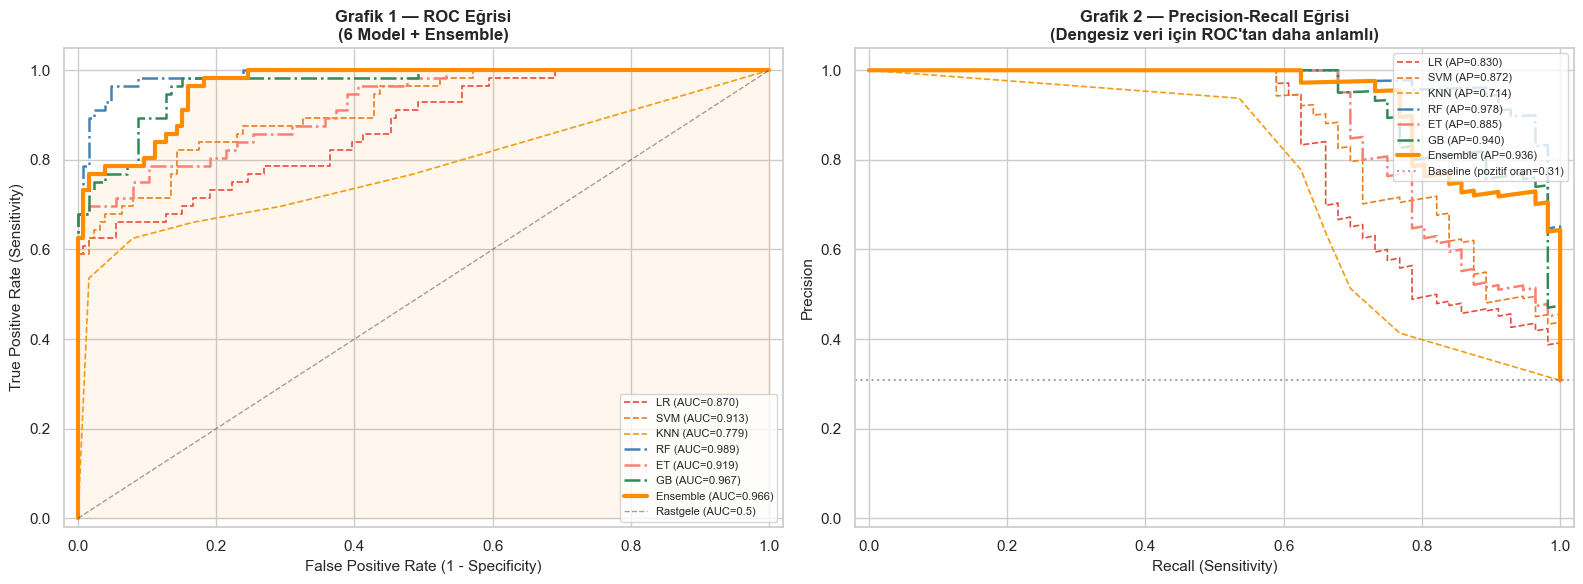

✓ Grafik 1-2 kaydedildi: figures/fig_roc_pr.png

=== AUC ÖZET (Temsili Split) ===
  LR        : ROC-AUC=0.870 | PR-AUC=0.830
  SVM       : ROC-AUC=0.913 | PR-AUC=0.872
  KNN       : ROC-AUC=0.779 | PR-AUC=0.714
  RF        : ROC-AUC=0.989 | PR-AUC=0.978
  ET        : ROC-AUC=0.919 | PR-AUC=0.885
  GB        : ROC-AUC=0.967 | PR-AUC=0.940
  Ensemble  : ROC-AUC=0.966 | PR-AUC=0.936


In [10]:
# ── Grafik 1-2: ROC ve Precision-Recall Eğrileri (6 Model + Ensemble) ────────
# ROC eğrisi: Her eşik için False Positive Rate vs True Positive Rate.
# AUC (Alan Altı Alan): 1.0 = mükemmel, 0.5 = rastgele tahmin.
#
# PR eğrisi: Precision vs Recall tradeoff.
# Dengesiz veri setlerinde PR-AUC, ROC-AUC'tan daha anlamlıdır:
# ROC negatif sınıftan etkilenirken PR yalnızca pozitif sınıfa (Papilödema) bakar.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tüm 6 model + Ensemble: renk ve stil tanımları
# Baseline modeller kesikli ince çizgi, ağaç modelleri kesikli kalın, Ensemble düz kalın
MODELLER = [
    ('LR',       y_prob_lr,  '#e74c3c', '--', 1.2),   # Kırmızı — baseline
    ('SVM',      y_prob_svm, '#e67e22', '--', 1.2),   # Turuncu — baseline
    ('KNN',      y_prob_knn, '#f39c12', '--', 1.2),   # Sarı — baseline
    ('RF',       y_prob_rf,  'steelblue', '-.', 1.8), # Mavi — ağaç
    ('ET',       y_prob_et,  'salmon',    '-.', 1.8), # Somon — ağaç
    ('GB',       y_prob_gb,  'seagreen',  '-.', 1.8), # Yeşil — ağaç
    ('Ensemble', y_prob_ens, 'darkorange', '-', 3.0), # Turuncu kalın — ENSEMBLE
]

# ── Grafik 1: ROC Eğrisi ──────────────────────────────────────────────────────
for isim, prob, renk, ls, lw in MODELLER:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    axes[0].plot(fpr, tpr, color=renk, linestyle=ls, linewidth=lw,
                 label=f'{isim} (AUC={auc:.3f})')

# Rastgele tahmin referans çizgisi (AUC=0.5)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1, label='Rastgele (AUC=0.5)')
# Ensemble altını hafifçe renklendir
fpr_e, tpr_e, _ = roc_curve(y_te, y_prob_ens)
axes[0].fill_between(fpr_e, tpr_e, alpha=0.07, color='darkorange')

axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes[0].set_title('Grafik 1 — ROC Eğrisi\n(6 Model + Ensemble)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.05)

# ── Grafik 2: Precision-Recall Eğrisi ────────────────────────────────────────
for isim, prob, renk, ls, lw in MODELLER:
    prec, rec, _ = precision_recall_curve(y_te, prob)
    ap = average_precision_score(y_te, prob)
    axes[1].plot(rec, prec, color=renk, linestyle=ls, linewidth=lw,
                 label=f'{isim} (AP={ap:.3f})')

# Baseline: sınıf oranı (Papilödema / Toplam) — rastgele PR performansı
baseline = y_te.mean()
axes[1].axhline(y=baseline, color='gray', linestyle=':', alpha=0.7,
                label=f'Baseline (pozitif oran={baseline:.2f})')

axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Grafik 2 — Precision-Recall Eğrisi\n(Dengesiz veri için ROC\'tan daha anlamlı)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig('../figures/fig_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Grafik 1-2 kaydedildi: figures/fig_roc_pr.png')

# Özet tablo
print('\n=== AUC ÖZET (Temsili Split) ===')
for isim, prob, *_ in MODELLER:
    auc = roc_auc_score(y_te, prob)
    ap  = average_precision_score(y_te, prob)
    print(f'  {isim:10s}: ROC-AUC={auc:.3f} | PR-AUC={ap:.3f}')


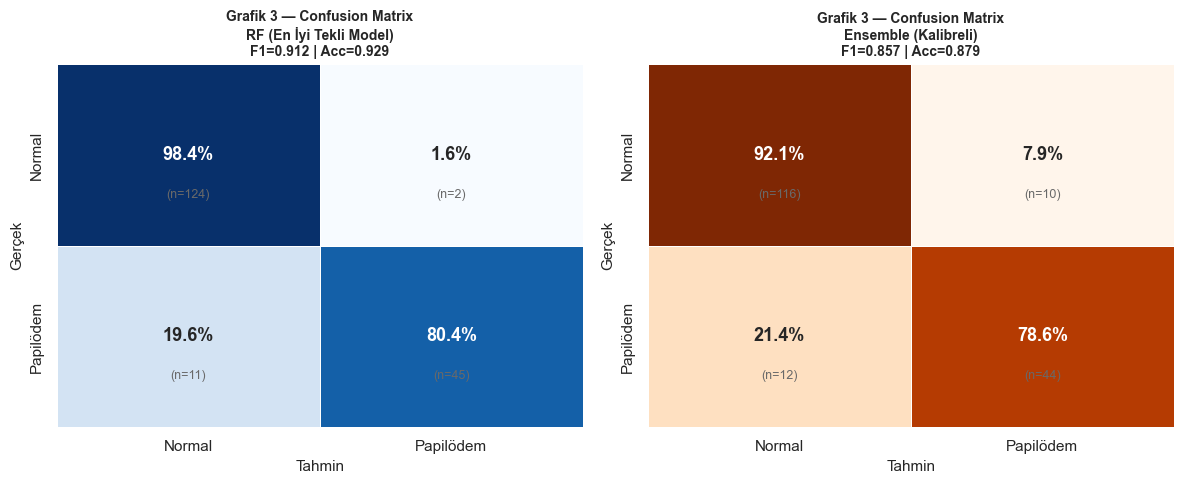

✓ Grafik 3 kaydedildi: figures/fig_confusion_matrix.png


In [11]:
# ── Grafik 3: Confusion Matrix — RF (En İyi Tekli) vs Ensemble ───────────────
# Confusion matrix: TP, TN, FP, FN görselleştirir.
#   TP (True Positive)  = Papilödema var, model doğru tahmin
#   TN (True Negative)  = Normal, model doğru tahmin
#   FP (False Positive) = Normal ama model Papilödema dedi (yanlış alarm)
#   FN (False Negative) = Papilödema var ama model Normal dedi (tehlikeli kaçırma)
#
# Klinik açıdan FN (hasta kaçırma) FP'den çok daha tehlikelidir.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
etiketler = ['Normal', 'Papilödem']

# RF (en iyi tekli model) ve Ensemble karşılaştırması
for ax, (isim, prob, renk) in zip(axes, [
    ('RF (En İyi Tekli Model)', y_prob_rf,  'Blues'),
    ('Ensemble (Kalibreli)',    y_prob_ens, 'Oranges')
]):
    y_pred = (prob >= 0.5).astype(int)  # Varsayılan eşik: 0.5
    cm = confusion_matrix(y_te, y_pred)

    # Normalize: satır toplamına böl → yüzde göster
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap=renk,
                xticklabels=etiketler, yticklabels=etiketler,
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={'size': 13, 'weight': 'bold'})

    # Ham sayıları da ekle (yüzdenin altına)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'(n={cm[i,j]})',
                    ha='center', va='center', fontsize=9, color='dimgray')

    f1  = f1_score(y_te, y_pred, average='macro')
    acc = accuracy_score(y_te, y_pred)
    ax.set_xlabel('Tahmin', fontsize=11)
    ax.set_ylabel('Gerçek', fontsize=11)
    ax.set_title(f'Grafik 3 — Confusion Matrix\n{isim}\nF1={f1:.3f} | Acc={acc:.3f}',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Grafik 3 kaydedildi: figures/fig_confusion_matrix.png')


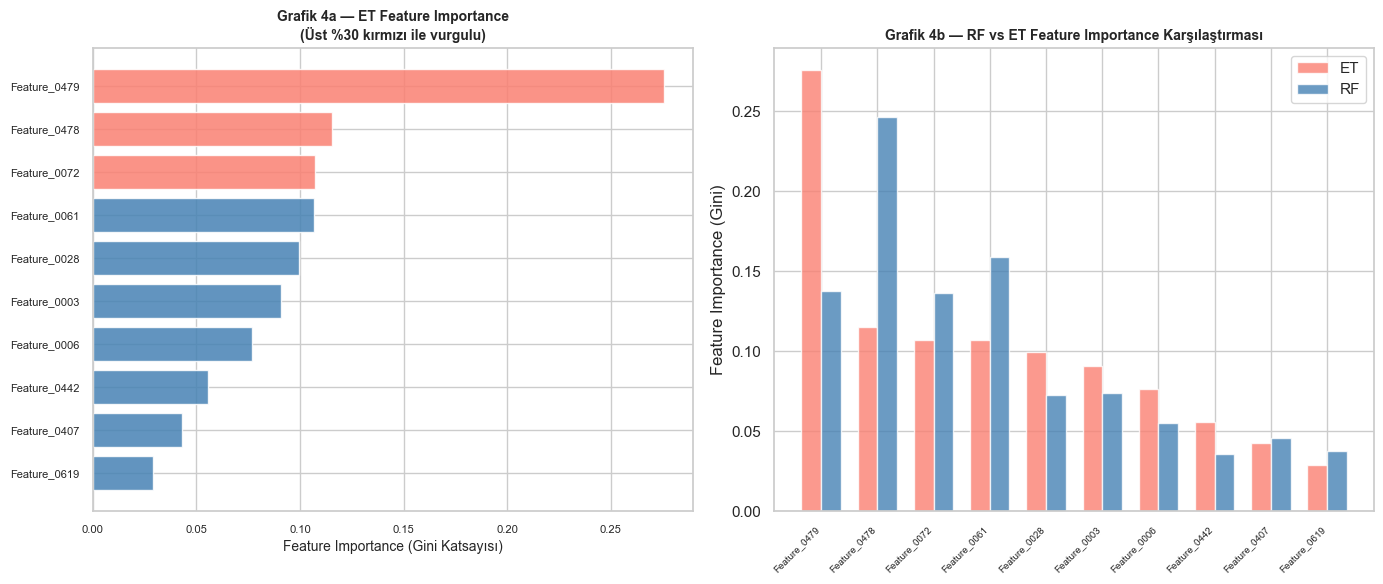

✓ Grafik 4 kaydedildi: figures/fig_feature_importance.png


In [12]:
# ── Grafik 4: Feature Importance — RF ve ET ─────────────────────────────────
# Feature importance (Gini): Bir özellik ağaçlarda dal ayırımında ne kadar
# kullanıldığını ölçer. Yüksek = model bu özelliğe güveniyor.
#
# NOT: Sadece ağaç modelleri feature_importances_ özelliğine sahiptir.
# LR → katsayılar (coefficients_) ile özellik önemini gösterir
# SVM → kernel SVM'de doğrudan özellik önemi hesaplanamaz
# KNN → mesafe tabanlı, doğrudan özellik önemi yok
# Bu nedenle feature importance grafiğinde RF ve ET kullanılmaktadır.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Sol: ET Feature Importance (tek model, renkli) ───────────────────────────
fi_et = pd.DataFrame({'feature': feats, 'importance': et.feature_importances_}) \
          .sort_values('importance', ascending=True)
fi_rf = pd.DataFrame({'feature': feats, 'importance': rf.feature_importances_}) \
          .sort_values('importance', ascending=True)

# Üst %30'u vurgula (en önemli özellikler)
colors_et = ['salmon' if imp > fi_et['importance'].quantile(0.7) else 'steelblue'
              for imp in fi_et['importance']]

axes[0].barh(fi_et['feature'], fi_et['importance'], color=colors_et, alpha=0.85)
axes[0].set_xlabel('Feature Importance (Gini Katsayısı)', fontsize=10)
axes[0].set_title('Grafik 4a — ET Feature Importance\n(Üst %30 kırmızı ile vurgulu)', fontsize=10, fontweight='bold')
axes[0].tick_params(labelsize=8)

# ── Sağ: RF vs ET karşılaştırması ────────────────────────────────────────────
fi_both = pd.DataFrame({'feature': feats,
                         'ET': et.feature_importances_,
                         'RF': rf.feature_importances_}) \
            .sort_values('ET', ascending=False)
x = np.arange(len(feats))
w = 0.35

axes[1].bar(x - w/2, fi_both['ET'], w, label='ET', color='salmon',    alpha=0.8)
axes[1].bar(x + w/2, fi_both['RF'], w, label='RF', color='steelblue', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fi_both['feature'], rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Feature Importance (Gini)')
axes[1].set_title('Grafik 4b — RF vs ET Feature Importance Karşılaştırması', fontsize=10, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Grafik 4 kaydedildi: figures/fig_feature_importance.png')


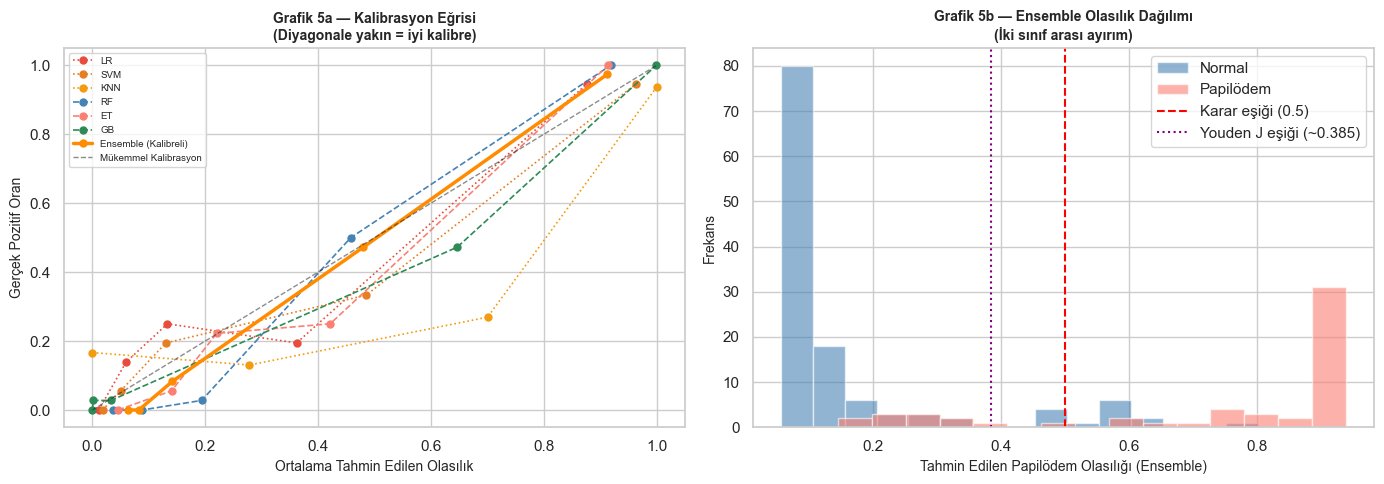

✓ Grafik 5 kaydedildi: figures/fig_kalibrasyon_dagilim.png


In [13]:
# ── Grafik 5: Kalibrasyon Eğrisi + Olasılık Dağılımı ────────────────────────
# Kalibrasyon eğrisi: Modelin tahmin ettiği olasılık gerçeği ne kadar yansıtıyor?
# Mükemmel kalibrasyonda: "0.8 olasılık" denen vakaların %80'i gerçekten pozitif.
# Diyagonale yakın = iyi kalibre edilmiş model.
#
# CalibratedClassifierCV(method='sigmoid') bu uyumu sağlamıştır.
# Sağ grafik: Ensemble'ın Normal ve Papilödema için ürettiği olasılık dağılımları.
# İki dağılım ne kadar az üstüste gelirse, model o kadar iyi ayırt ediyor.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sol: Kalibrasyon eğrisi — ağaç modelleri + Ensemble ─────────────────────
# Baseline modeller (LR, SVM, KNN) de gösteriliyor — karşılaştırma için
for isim, prob, renk, ls in [
    ('LR',                y_prob_lr,  '#e74c3c',    ':'),
    ('SVM',               y_prob_svm, '#e67e22',    ':'),
    ('KNN',               y_prob_knn, '#f39c12',    ':'),
    ('RF',                y_prob_rf,  'steelblue',  '--'),
    ('ET',                y_prob_et,  'salmon',     '--'),
    ('GB',                y_prob_gb,  'seagreen',   '--'),
    ('Ensemble (Kalibreli)', y_prob_ens, 'darkorange', '-'),
]:
    try:
        frac_pos, mean_pred = calibration_curve(y_te, prob, n_bins=5, strategy='quantile')
        lw = 2.5 if isim == 'Ensemble (Kalibreli)' else 1.2
        axes[0].plot(mean_pred, frac_pos, marker='o', color=renk,
                     linestyle=ls, linewidth=lw, markersize=5, label=isim)
    except Exception:
        pass  # Bazı split'lerde yeterli örnek olmayabilir

# Mükemmel kalibrasyon referansı
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Mükemmel Kalibrasyon')
axes[0].set_xlabel('Ortalama Tahmin Edilen Olasılık', fontsize=10)
axes[0].set_ylabel('Gerçek Pozitif Oran', fontsize=10)
axes[0].set_title('Grafik 5a — Kalibrasyon Eğrisi\n(Diyagonale yakın = iyi kalibre)', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=7)

# ── Sağ: Ensemble olasılık dağılımı ─────────────────────────────────────────
prob_normal = y_prob_ens[y_te == 0]   # Normal hastaların Ensemble olasılıkları
prob_papil  = y_prob_ens[y_te == 1]   # Papilödema hastalarının Ensemble olasılıkları

axes[1].hist(prob_normal, bins=15, alpha=0.6, color='steelblue',
             label='Normal', edgecolor='white')
axes[1].hist(prob_papil,  bins=15, alpha=0.6, color='salmon',
             label='Papilödem', edgecolor='white')
# Varsayılan karar eşiği
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5,
                label='Karar eşiği (0.5)')
# Optimal Youden J eşiği (07 notebook'tan: ~0.385)
axes[1].axvline(0.385, color='purple', linestyle=':', linewidth=1.5,
                label='Youden J eşiği (~0.385)')

axes[1].set_xlabel('Tahmin Edilen Papilödem Olasılığı (Ensemble)', fontsize=10)
axes[1].set_ylabel('Frekans', fontsize=10)
axes[1].set_title('Grafik 5b — Ensemble Olasılık Dağılımı\n(İki sınıf arası ayırım)', fontsize=10, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig_kalibrasyon_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Grafik 5 kaydedildi: figures/fig_kalibrasyon_dagilim.png')


✓ Bireysel model F1 skorları yüklendi: (20, 6)
  Sütunlar: ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']


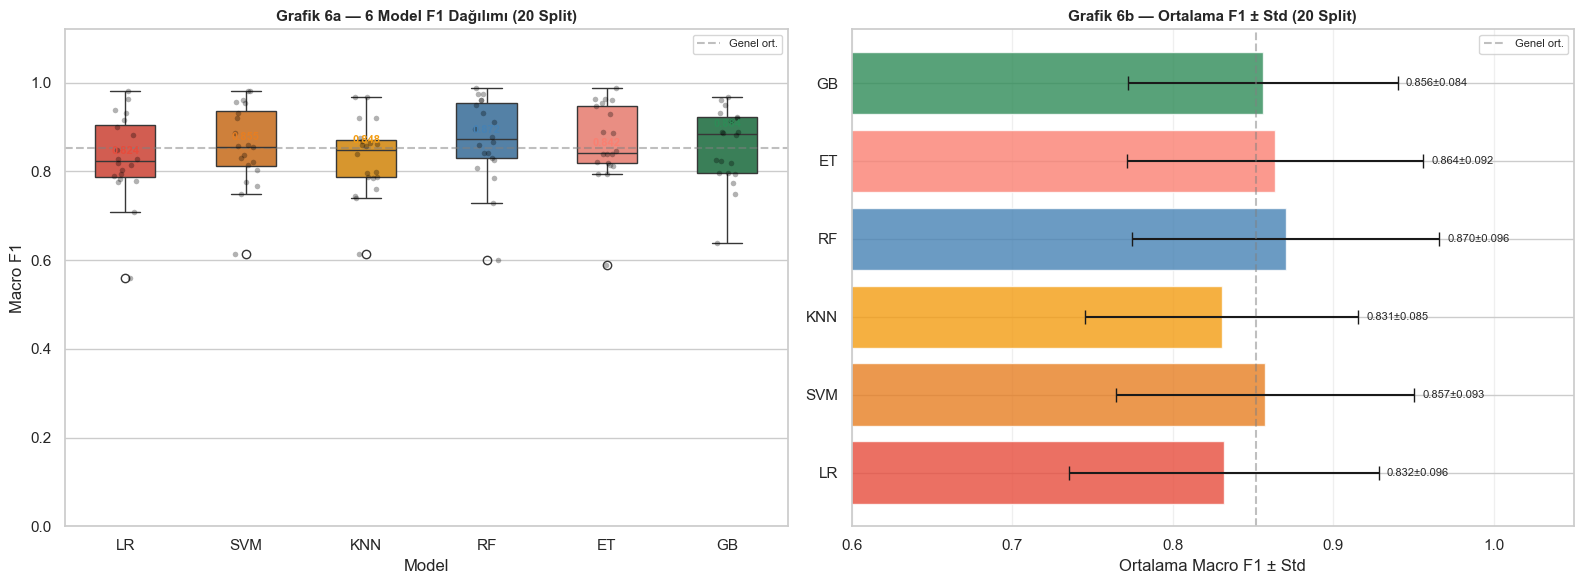

✓ Grafik 6 kaydedildi: figures/fig_model_karsilastirma_6model.png


In [14]:
# ── Grafik 6: 6 Model Karşılaştırması (20 Split Sonuçları) ──────────────────
# Bu grafik 07 notebook'unun ürettiği bireysel_model_f1_skorlari.csv'yi kullanır.
# 07 notebook'u çalıştırılmamışsa bu grafik oluşturulamaz.
#
# Sol: Box plot — 20 split boyunca F1 dağılımı (varyans ve medyan görünür)
# Sağ: Bar grafik — ortalama F1 ± standart sapma (hangisi daha stabil?)

import os

bireysel_path = '../results/bireysel_model_f1_skorlari.csv'

if os.path.exists(bireysel_path):
    f1_df = pd.read_csv(bireysel_path)
    print(f'✓ Bireysel model F1 skorları yüklendi: {f1_df.shape}')
    print(f'  Sütunlar: {list(f1_df.columns)}')
else:
    print('⚠️ Bireysel model sonuçları bulunamadı!')
    print('   Lütfen önce 07_istatistiksel_analiz.ipynb çalıştırın.')
    f1_df = None

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

MODELLER_RENK = {
    'LR' : '#e74c3c',   # Kırmızı — baseline
    'SVM': '#e67e22',   # Turuncu — baseline
    'KNN': '#f39c12',   # Sarı — baseline
    'RF' : 'steelblue', # Mavi — ağaç
    'ET' : 'salmon',    # Somon — ağaç
    'GB' : 'seagreen',  # Yeşil — ağaç
}
MODEL_SIRASI = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']

if f1_df is not None:
    # Yalnızca mevcut sütunları kullan
    mevcut = [m for m in MODEL_SIRASI if m in f1_df.columns]

    # ── Sol: Box + Strip plot ─────────────────────────────────────────────────
    long = f1_df[mevcut].melt(var_name='Model', value_name='Macro F1')
    palette = {m: MODELLER_RENK[m] for m in mevcut}

    sns.boxplot(data=long, x='Model', y='Macro F1',
                palette=palette, ax=axes[0], width=0.5, order=mevcut)
    sns.stripplot(data=long, x='Model', y='Macro F1',
                  color='black', alpha=0.3, size=4, jitter=True,
                  ax=axes[0], order=mevcut)

    # Medyan değeri her kutunun üstüne yaz
    for i, m in enumerate(mevcut):
        med = f1_df[m].median()
        axes[0].text(i, med + 0.015, f'{med:.3f}',
                     ha='center', fontsize=8, fontweight='bold',
                     color=MODELLER_RENK[m])

    axes[0].set_title('Grafik 6a — 6 Model F1 Dağılımı (20 Split)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Macro F1')
    axes[0].set_ylim(0, 1.12)
    axes[0].axhline(f1_df[mevcut].values.mean(), color='gray',
                    linestyle='--', alpha=0.5, label='Genel ort.')
    axes[0].legend(fontsize=8)

    # ── Sağ: Bar grafik — Ortalama ± Std ─────────────────────────────────────
    means = f1_df[mevcut].mean()
    stds  = f1_df[mevcut].std()
    colors = [MODELLER_RENK[m] for m in mevcut]

    axes[1].barh(mevcut, [means[m] for m in mevcut],
                 xerr=[stds[m] for m in mevcut],
                 color=colors, alpha=0.8, edgecolor='white', capsize=5)
    axes[1].set_xlabel('Ortalama Macro F1 ± Std')
    axes[1].set_title('Grafik 6b — Ortalama F1 ± Std (20 Split)', fontsize=11, fontweight='bold')
    axes[1].set_xlim(0.6, 1.05)
    axes[1].axvline(means.mean(), color='gray', linestyle='--', alpha=0.5, label='Genel ort.')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, axis='x', alpha=0.3)

    # Her barın yanına değeri yaz
    for i, m in enumerate(mevcut):
        axes[1].text(means[m] + stds[m] + 0.005, i,
                     f'{means[m]:.3f}±{stds[m]:.3f}',
                     va='center', fontsize=8)

else:
    for ax in axes:
        ax.text(0.5, 0.5, '07 notebook çalıştırılmamış\nbileysel_model_f1_skorlari.csv bulunamadı',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='red')

plt.tight_layout()
plt.savefig('../figures/fig_model_karsilastirma_6model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Grafik 6 kaydedildi: figures/fig_model_karsilastirma_6model.png')


In [15]:
# ── Performans Grafikleri Özeti ──────────────────────────────────────────────
print('=' * 65)
print('PERFORMANS GRAFİKLERİ — ÖZET')
print('=' * 65)
print('Üretilen grafikler:')
print('  1. fig_roc_pr.png              — ROC + PR eğrisi (6 model + Ensemble)')
print('  2. fig_confusion_matrix.png    — Confusion matrix (RF vs Ensemble)')
print('  3. fig_feature_importance.png  — Feature importance (RF + ET)')
print('  4. fig_kalibrasyon_dagilim.png — Kalibrasyon eğrisi (7 model) + dağılım')
print('  5. fig_model_karsilastirma_6model.png — 6 model F1 karşılaştırması')
print()
print('Temsili split üzerinden anlık AUC değerleri:')
from sklearn.metrics import roc_auc_score, average_precision_score
PROB_DICT = {
    'LR': y_prob_lr, 'SVM': y_prob_svm, 'KNN': y_prob_knn,
    'RF': y_prob_rf, 'ET': y_prob_et,   'GB': y_prob_gb,
    'Ensemble': y_prob_ens
}
for isim, prob in PROB_DICT.items():
    auc = roc_auc_score(y_te, prob)
    ap  = average_precision_score(y_te, prob)
    f1  = f1_score(y_te, (prob >= 0.5).astype(int), average='macro', zero_division=0)
    print(f'  {isim:10s}: ROC-AUC={auc:.3f} | PR-AUC={ap:.3f} | F1={f1:.3f}')
print('=' * 65)
print('\nSıradaki adım → SHAP Analizi (aşağıdaki hücreler)')


PERFORMANS GRAFİKLERİ — ÖZET
Üretilen grafikler:
  1. fig_roc_pr.png              — ROC + PR eğrisi (6 model + Ensemble)
  2. fig_confusion_matrix.png    — Confusion matrix (RF vs Ensemble)
  3. fig_feature_importance.png  — Feature importance (RF + ET)
  4. fig_kalibrasyon_dagilim.png — Kalibrasyon eğrisi (7 model) + dağılım
  5. fig_model_karsilastirma_6model.png — 6 model F1 karşılaştırması

Temsili split üzerinden anlık AUC değerleri:
  LR        : ROC-AUC=0.870 | PR-AUC=0.830 | F1=0.815
  SVM       : ROC-AUC=0.913 | PR-AUC=0.872 | F1=0.810
  KNN       : ROC-AUC=0.779 | PR-AUC=0.714 | F1=0.745
  RF        : ROC-AUC=0.989 | PR-AUC=0.978 | F1=0.912
  ET        : ROC-AUC=0.919 | PR-AUC=0.885 | F1=0.838
  GB        : ROC-AUC=0.967 | PR-AUC=0.940 | F1=0.886
  Ensemble  : ROC-AUC=0.966 | PR-AUC=0.936 | F1=0.857

Sıradaki adım → SHAP Analizi (aşağıdaki hücreler)


---
## Bonus F — SHAP Analizi (Model Yorumlanabilirliği)

**SHAP (SHapley Additive exPlanations)** — oyun teorisinden ilham alan bu yöntem,  
her özelliğin her tahmine katkısını matematiksel olarak ölçer.  
Kara kutu modeli açar: *neden* bu karar verildi sorusuna cevap verir.

> *Finans analojisi: SHAP = portföy getiri attribution — hangi pozisyon ne kadar kazandırdı?*


In [19]:
# SHAP kütüphanesini yükle (yoksa)
import subprocess, sys
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    print('SHAP yükleniyor...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print(f'✓ SHAP yüklendi: {shap.__version__}')


SHAP version: 0.51.0


In [20]:
import shap
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

# Representatif split (split_no=0) kullan — cell 3'te zaten hazır
# fitted_rf, X_te_m, y_te, feats değişkenlerini cell 3'ten alıyoruz
# Eğer cell 3 çalıştırılmadıysa tekrar çalıştırın

print('SHAP değerleri hesaplanıyor (TreeExplainer)...')
shap_explainer = shap.TreeExplainer(fitted_rf)
shap_values = shap_explainer.shap_values(X_te_m)  # shape: (n_samples, n_features, 2) veya list

# sklearn RF için shap_values liste olarak gelir: [class0, class1]
# class1 (Papilödema) için değerleri alalım
if isinstance(shap_values, list):
    sv_class1 = shap_values[1]   # Papilödema sınıfı
else:
    sv_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(f'✓ SHAP değerleri hesaplandı — shape: {sv_class1.shape}')
print(f'Özellik isimleri: {feats}')


SHAP değerleri hesaplanıyor (TreeExplainer)...
✓ SHAP değerleri hesaplandı — shape: (182, 10)
Özellik isimleri: ['Feature_0072', 'Feature_0407', 'Feature_0619', 'Feature_0479', 'Feature_0478', 'Feature_0442', 'Feature_0006', 'Feature_0003', 'Feature_0028', 'Feature_0061']


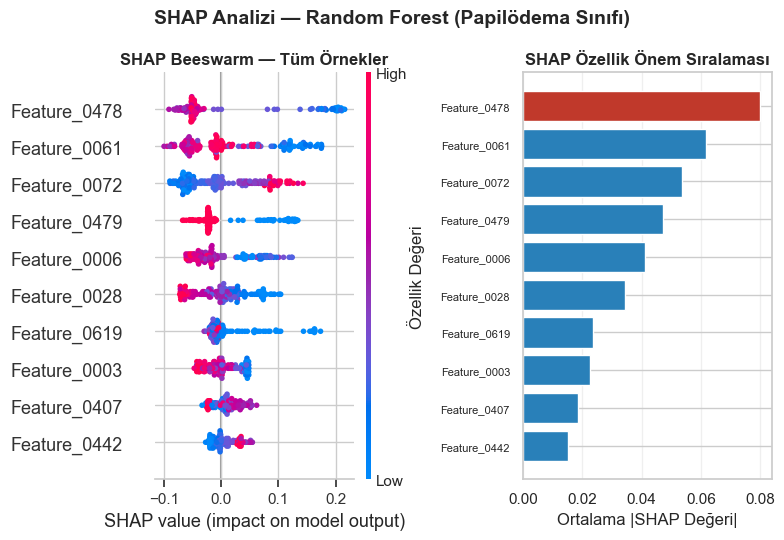

✓ fig_shap_analizi.png kaydedildi


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Analizi — Random Forest (Papilödema Sınıfı)', fontsize=14, fontweight='bold')

# ---- Sol: SHAP Beeswarm (Summary) Grafiği ----
plt.sca(axes[0])
shap.summary_plot(
    sv_class1, X_te_m,
    feature_names=[f[:30] for f in feats],
    show=False, plot_type='dot',
    color_bar_label='Özellik Değeri'
)
axes[0].set_title('SHAP Beeswarm — Tüm Örnekler', fontweight='bold')

# ---- Sağ: SHAP Bar (Mean Absolute) ----
plt.sca(axes[1])
mean_abs_shap = np.abs(sv_class1).mean(axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_n = min(10, len(feats))
top_idx = sorted_idx[:top_n]

bars = axes[1].barh(
    range(top_n),
    mean_abs_shap[top_idx][::-1],
    color=['#c0392b' if mean_abs_shap[i] == mean_abs_shap[top_idx[0]] else '#2980b9'
           for i in top_idx[::-1]]
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feats[i][:35] for i in top_idx[::-1]], fontsize=8)
axes[1].set_xlabel('Ortalama |SHAP Değeri|')
axes[1].set_title('SHAP Özellik Önem Sıralaması', fontweight='bold')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_shap_analizi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_shap_analizi.png kaydedildi')


Örnek idx: 126 | Gerçek label: 1 | RF prob: 0.556


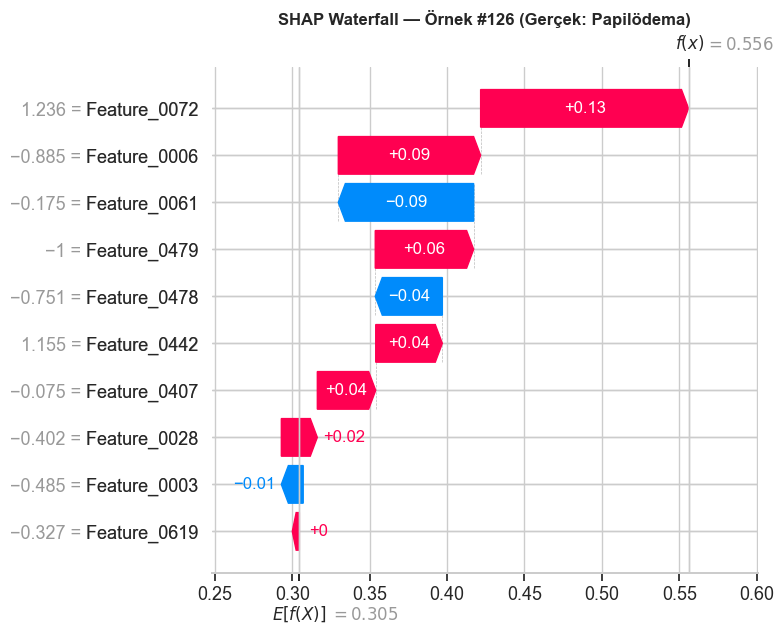

✓ fig_shap_waterfall.png kaydedildi

=== SHAP ÖZET ===
     Ozellik  Ortalama_SHAP
Feature_0478         0.0799
Feature_0061         0.0617
Feature_0072         0.0536
Feature_0479         0.0471
Feature_0006         0.0412
Feature_0028         0.0344
Feature_0619         0.0236
Feature_0003         0.0227
Feature_0407         0.0184
Feature_0442         0.0151


In [22]:
# ---- Waterfall grafiği: Tek bir örnek için SHAP açıklaması ----
# Papilödema olarak tahmin edilen ilk örneği göster
y_prob_test = fitted_rf.predict_proba(X_te_m)[:, 1]
papil_idx = np.where(y_te == 1)[0]
if len(papil_idx) > 0:
    ornek_idx = papil_idx[0]  # İlk gerçek papilödema örneği
else:
    ornek_idx = 0

print(f'Örnek idx: {ornek_idx} | Gerçek label: {y_te[ornek_idx]} | RF prob: {y_prob_test[ornek_idx]:.3f}')

# Waterfall için Explanation objesi oluştur
base_value = shap_explainer.expected_value[1] if isinstance(shap_explainer.expected_value, (list, np.ndarray)) else shap_explainer.expected_value
explanation = shap.Explanation(
    values=sv_class1[ornek_idx],
    base_values=base_value,
    data=X_te_m[ornek_idx],
    feature_names=[f[:30] for f in feats]
)

fig, ax = plt.subplots(figsize=(10, 5))
shap.waterfall_plot(explanation, show=False)
plt.title(f'SHAP Waterfall — Örnek #{ornek_idx} (Gerçek: {"Papilödema" if y_te[ornek_idx]==1 else "Normal"})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_shap_waterfall.png kaydedildi')

print('\n=== SHAP ÖZET ===')
shap_ozet = pd.DataFrame({'Ozellik': feats, 'Ortalama_SHAP': mean_abs_shap})
shap_ozet = shap_ozet.sort_values('Ortalama_SHAP', ascending=False)
print(shap_ozet.round(4).to_string(index=False))
